## Testing Matched Filter + Connected Component Denoising
This notebook demonstrates the effectiveness of a single-size matched filter implementation on an image of a microcrack.

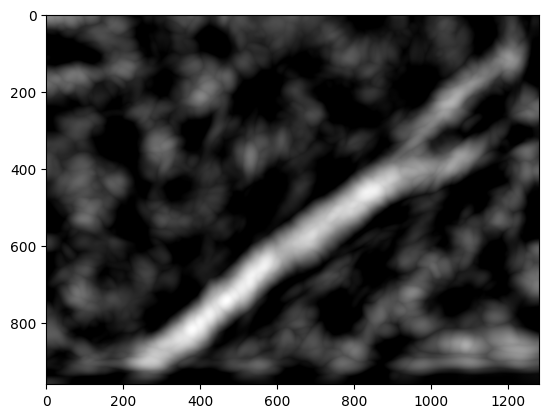

In [73]:
import matched_filter as mf
import matplotlib.pyplot as plt

templates = mf.generate_kernels(sigma=44.0, L=54, angle_step=15)
mask, response = mf.apply_matched_filter_from_path("../images/0098.tif", templates, 0.5)
plt.imshow(response, cmap="gray")
plt.show()

Above shows the **response** of applying the matched filter. Note that multiple matched filters are actually being used (12 to be exact). It seems to response well to the crack as shown below (after denoising).

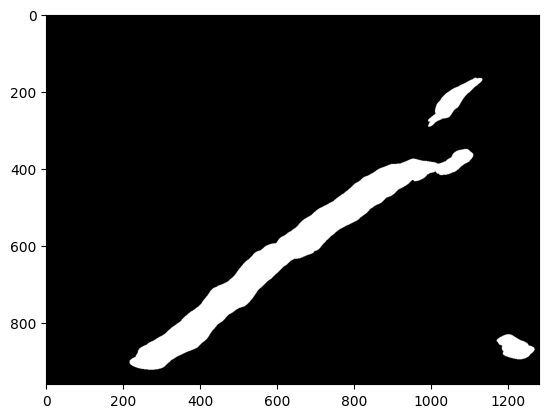

In [74]:
cleaned = mf.ccd(mask, int(mask.size / 500))
plt.imshow(cleaned, cmap='gray')
plt.show()

We can test the effectiveness of the matched filter by calculating the IoU, dice score, and percent error using an annotated image.

In [75]:
import score
import cv2

ground_truth = cv2.imread('../images/annotated/0098.png', cv2.IMREAD_GRAYSCALE)
assert ground_truth is not None
score.iou(cleaned, ground_truth)

0.652206578568194

In [76]:
assert ground_truth is not None
score.precision(cleaned, ground_truth)

0.7876576968491703

In [77]:
assert ground_truth is not None
score.recall(cleaned, ground_truth)

0.7913461538461538

In [78]:
assert ground_truth is not None
score.dice(cleaned, ground_truth)

0.7894976173420126

In [79]:
assert ground_truth is not None
score.percent_err(cleaned, ground_truth)

0.027500813802083333

In [80]:
assert ground_truth is not None
score.percent_success(cleaned, ground_truth)

0.9724991861979166

## Results Summary
**Dice score** usually measures something closer to average-case performance while **IoU** measures something closer to worst-case performance. With the parameters above, we get the following:

- Dice score: `78.95%`
- IoU: `65.22%`

However, both weigh pixel errors inversely proportional to the size of the relevant set rather than weighing them equally. This can lead to large penalties on trivial mistakes with small selected ground truths. Therefore, we have also measured percent error:

- Percent error: `2.75%`

Which is the complement of percent success (`97.25%`).